## Multi-armed bandits

### Learning outcomes

The learning outcomes of this chapter are:

1. Select and apply multi-armed bandit algorithms

### Overview

*Multi-armed bandit* techniques are not techniques for solving MDPs, but it turns out that they are used throughout a lot of reinforcement learning techniques that do solve for MDPs.

The problem of multi-armed bandits can be illustrated as follows:

> Imagine that you have $N$ number of slot machines (or poker machines in Australia), which are sometimes called *one-armed bandits*. Over  time, each bandit pays a random reward from an unknown probability distribution. Some bandits pay higher rewards than others. The goal is to maximize the sum of the rewards of a sequence of lever pulls of the  machine.

The question is: over an infinite period of time, without knowing the probability distribution beforehand, how should we select the arms. Multi-armed bandit techniques aim to solve this problem. 

### The multi-armed bandit problem

:::{admonition} Definition

A **multi-armed bandit** (also known as an **$N$-armed bandit**) is defined by a set of *random variables* $X_{i,k}$ where:

-   $1 \leq i \leq N$, such that $i$ is the *arm* of the bandit; and

-   $k$ the index of the *play* of arm $i$;

Successive plays $X_{i,1}, X_{j,2}, X_{k,3}\ldots$ are assumed to be independently distributed, but we do not know the probability distributions of the random variables.

The idea is that a gambler iteratively plays rounds, observing the reward from the arm after each round, and can adjust their strategy each time. The aim is to maximise the sum of the rewards collected over all  rounds.

:::

Given that we do not know the distributions, a simple strategy is simply to select the arm given a uniform distribution; that is, select each arm with the same probability. This is just uniform sampling.

Then, the Q-value for an action $a$ can be estimated using the following formula:

$$Q(a) = \frac{1}{N(a)} \sum_{i=1}^{t} {\mathbb I}_{i}(a) r_i$$

where $t$ is the number of rounds so far, $N(a)$ is the number of times $a$ selected in previous rounds, $r_i$ is the *reward* obtained in the $i$-th round, and  $\mathbb{I}_{i}(a)$ is $1$ if $a$ was selected on the $i$-th round, and is $0$ otherwise.

The idea here is that for a multi-armed bandit problem, we explore the options uniformly for some time, and then once we are confident we have enough samples (when the changes to the values of $Q(a)$ start to stabilise), we start selecting $\max_a Q(a)$. This is a strategy known as *$\epsilon$-first* strategy, where the parameter $\epsilon$ (epsilon), determines how many rounds to select random actions before moving to the greedy action.

**But what is the issue?** Time is wasted equally in all actions using the uniform distribution. Why not focus also on the *most promising actions* given the rewards we have received so far.

### Exploration vs. Exploitation

What we want is to play only the good actions; so just keep playing the actions that have given us the best reward so far. However, our selection is randomised, so what if we just haven't sampled the best action enough times? Thus, we want strategies that *exploit* what we think are the best actions so far, but still *explore* other actions.

But how much should we exploit and how much should we explore? This is known as the *exploration vs. exploitation dilemma*. It is driven by the *The Fear of Missing Out* (FOMO). FOMO drives us to search for strategies that *minimise regret*.

:::{definition}(Pseudo)--Regret 
Pseudo-regret is defined formally as:

 $$\mathcal {R_{N,b} }  =  \max_a Q(a) N(s) - \mathbb{E} [ \sum_{i}^{t} Q(b) \mathbb{I}_{i}(b) ]$$

where $t$ is the number of rounds, $\mathbb{I}_{i}(a)$ is $1$ if $a$ was selected on the $i$-th round and $0$ otherwise, and ${\mathbb E}[ \sum_{i}^{t} Q(b) \mathbb{I}_{i}(b)] > 0$ for every $b$.
:::

Informally: If I take action $b$, my regret is the *best possible expected reward* minus the *expected reward of playing $b$*. If I take action $a$ (the best action), my regret is 0. So, regret is the *expected loss* from not taking the best action.

A *zero-regret* strategy is a strategy whose average regret each round approaches zero as the number of rounds approached infinity. So, this means that a zero-regret strategy will converge to an optimal strategy given enough rounds.

### Solutions for minimising regret

There are several basic strategies for minimising regret. In each of these techniques, we record the average return of each arm over time. For consistency with the rest of these notes, we will call these Q-values, and will use $Q(a)$ to represent the Q value of arm $a$.

### Epsilon-greedy strategy

The $\epsilon$-greedy strategy  is a simple and effective way of balancing exploration and exploitation. In this algorithm, the parameter $\epsilon \in [0,1]$ (pronounced "epsilon") controls how much we explore and how much we exploit. 

Each time we need to choose an action, we do the following:

- With probability $\epsilon$ we choose the arm with the maximum Q value: $\textrm{argmax}_a Q(a)$. If there is a tie between multiple actions with the larget Q-value, break the tie.
- With probability $1-\epsilon$ we choose a random arm with uniform probability.

The best value for $\epsilon$ depends on the particular problem, but typically, values around 0.05-0.1 work well as they exploit what they have learnt.

### Epsilon-decreasing

This follows a similar idea to epsilon greedy, however, it recognises that initially, we have very little feedback so exploiting is not a good strategy to being with: we need to explore first. Then, it recognises that as we gather more data, we should exploit more.

It does this by taking the basic epsilon greedy strategy and introducing another parameter $\alpha$ (pronounced "alpha"), which is used to decrease $\epsilon$ over time. For this reason, $\alpha$ is called the *decay$.

The selection mechanism is the same as epsilon greedy, but then after each selection, we set  $\epsilon := \epsilon \times \alpha$. We start initially with a higher value of $\epsilon$ to explore, and it will slowly decay to a low number such that we explore less and less as we gather more feedback.

### Softmax

Softmax  is *probability matching strategy*, which means that the probability of each action being chosen is dependent on its Q-value so far. Formally, softmax chooses an action because on the *Boltzman* distribution for that action:

$$\frac{e^{Q(a)/\tau}}{\sum_{b=1}^{N} e^{Q(b)/\tau}}$$ 

where $N$ is the number of arms, and $\tau$ (pronounced "tau") is the *temperature*, a positive number that dictates how much of an influence the past data has on the decision. A higher value of $\tau$ would mean that the probability of selecting each action is close to each other, while a lower value of $\tau$ would imply that the probabilities are closer to their Q values. When $\tau=1$, the probabilities are just $e^{Q(a)}$.

As with epsilon decreasing, we can add a decay parameter $\alpha$ that allows the value of $\tau$ to decay until it reaches 1. This encourages exploration in earlier phases, and exploration less as we gather more feedback.

### Upper Confidence Bounds (UCB1)

A highly effective multi-armed bandit strategy is the *Upper Confidence Bounds* (UCB1) strategy.

Using the UCB1 strategy, we select the next action  using the following:

$$\textrm{argmax}_{a}\left(Q(a)   +   \sqrt{\frac{2 \ln t}{N(a)}}\right)$$

where $t$ is the number of rounds so far, and $N(a)$ is the number of times times $a$ has been chosen in all previous rounds. The term inside the square root is undefined if $N(a) = 0$. The avoid this, the typical strategy is to spend the first $N$ rounds to select each of the $N$ bandits once.

The left--hand side encourages exploitation: the Q-value is high for actions that have had a high reward.

The right--hand side encourages exploration: it is high for actions that have been explored less -- that is, when $N(a)$ relative to other actions.

Interesting, the UCB formula is not a weighted formula -- that is, there is no parameter giving weight to the $Q(a)$ or the square root expressions to balance exploration vs. exploitation. So how does it work? We will not get into all the details, but instead just give some intuition.

We want to learn the Q-function, which gives us the average return on each action $a$, such that it approximates the real (unknown) Q-function, which we will call $Q^*$. At each round, we select the action $a$ that maximises the expression inside the brackets. If arm $a$ is optimal, then we want the following to hold for all actions $b \neq a$:

$$Q(b) + sqrt{\frac{2 \ln t}{N(a)}} \leq Q^*(a)$$

If this holds, we have some confidence that $Q(a)$ is optimal. If $N(b)$ is low for some actions, we do not have this confidence. 

If by chance the above expression does NOT hold for the optimal action $a$, then $a$ is disregarded, but should not be. We want this to occur only with probability $\frac{1}{N}$ to maximise pseudo-regret. This leads us to $\ln t$ in the expression. We will not go into the technicalities of why $\ln t$ in these notes.

## Implementation

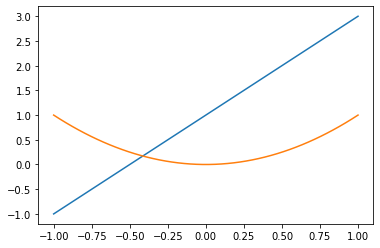

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-1, 1, 50)
y = 2*x + 1
z = x*x

plt.plot(x, y)
plt.plot(x, z)
plt.show()